# Solar Diameter Fit: Limb-Brightened Disk + Sunspot Floor

## Purpose

Fit a physically motivated 3-parameter visibility model to the fringe envelope, with the solar radius $R$ fixed per channel from the geometric extrema analysis in notebook 05b and the baseline fixed from notebook 04.

## Starting point: the measurement equation

The AY 121 lab manual ([`interf.tex`](../../../src/ugradio/lab_interf/interf.tex), eq. `interfeqn`) derives the interferometer response to an extended source as the product of the point-source fringe and the Fourier transform of the source brightness — the one-dimensional van Cittert-Zernike theorem. The astrobaki "Basic Interferometry II" page gives the full 2-D form:

$$V(u,v) = \iint I(l,m)\,e^{-2\pi i(ul + vm)}\,dl\,dm.$$

For a circularly symmetric source, this reduces to a Hankel transform (theory notebook §1.5):

$$V(q) = 2\pi \int_0^R I(\rho)\,J_0(2\pi q\rho)\,\rho\,d\rho,$$

where $q = \sqrt{u^2 + v^2}$ is the projected baseline length in wavelengths.

## Step 1: Uniform disk $\to$ jinc (the lab-manual model)

The lab manual (§8, "Measuring the Diameter of a Circular Source") assumes a uniformly bright disk $I(\rho) = I_0$ and writes the modulating function as the integral $\frac{1}{R}\int_{-R}^{R}\sqrt{R^2-\Delta h^2}\cos(2\pi f_f \Delta h)\,d\Delta h$, noting that it evaluates to a Bessel function. The 2-D Hankel form makes this explicit: using the standard identity $\int_0^R J_0(a\rho)\,\rho\,d\rho = R\,J_1(aR)/a$,

$$V_{\mathrm{disk}}(q) = I_0\,\pi R^2 \cdot \frac{2\,J_1(2\pi q R)}{2\pi q R}.$$

The prefactor $I_0 \pi R^2$ is the total flux; defining $A \equiv I_0 \pi R^2$ so that $V_{\mathrm{disk}}(0) = A$, the normalised visibility is the **jinc**: $V_{\mathrm{disk}}/A = 2J_1(x)/x$ with $x = 2\pi q R$.

## Step 2: Generalise to a limb-brightened disk

The lab manual acknowledges the Sun is not uniformly bright. At centimetre wavelengths the chromospheric temperature increases with height, making the solar limb brighter than the disk centre — the opposite of optical limb darkening ([Dulk85] §III; [Selhorst04]; see notebook 05 §7.3 for observational references). The simplest extension that preserves circular symmetry is a quadratic radial profile:

$$I(\rho) = I_0\!\left[1 + \varepsilon\!\left(\frac{\rho}{R}\right)^{\!2}\right], \qquad \rho \le R,$$

where $\varepsilon > 0$ parametrises the limb excess. Substituting into the Hankel transform:

$$V(q) = 2\pi I_0 \int_0^R \!\left[1 + \varepsilon\!\left(\frac{\rho}{R}\right)^{\!2}\right] J_0(2\pi q\rho)\,\rho\,d\rho
       = \underbrace{2\pi I_0 \int_0^R J_0(2\pi q\rho)\,\rho\,d\rho}_{\text{uniform disk}} \;+\; \underbrace{\frac{2\pi I_0\,\varepsilon}{R^2}\int_0^R \rho^3\,J_0(2\pi q\rho)\,d\rho}_{\text{quadratic (limb) term}}.$$

The first integral is the standard jinc above. For the second, substitute $t = \rho/R$:

$$\int_0^R \rho^3\,J_0(2\pi q\rho)\,d\rho = R^4 \int_0^1 t^3\,J_0(x\,t)\,dt, \qquad x = 2\pi q R.$$

The total flux is $V(0) = I_0\pi R^2(1 + \varepsilon/2)$, so normalising:

$$\boxed{V_{\mathrm{lb}}(q) = \frac{\frac{2\,J_1(x)}{x} \;+\; \varepsilon\cdot 2\!\int_0^1 t^3\,J_0(x\,t)\,dt}{1 + \varepsilon/2},}$$

where the denominator ensures $V_{\mathrm{lb}}(0) = 1$ (using $2J_1(x)/x \to 1$ and $2\int_0^1 t^3\,dt = 1/2$ as $x \to 0$). The integral $\int_0^1 t^3 J_0(xt)\,dt$ is precomputed as a lookup table in the implementation below.

## Step 3: Add an unresolved sunspot

By the linearity of the van Cittert-Zernike theorem ([`interf.tex`](../../../src/ugradio/lab_interf/interf.tex) eq. `interfeqn`; theory notebook §1.7), the visibility of a composite source is the sum of its components' visibilities. An unresolved sunspot at unknown position on the disk contributes a point-source visibility with constant amplitude $f$ (the spot's flux as a fraction of the disk flux) but **unknown phase** $\phi(q)$ set by its angular offset:

$$V_{\mathrm{total}}(q) = A\,V_{\mathrm{lb}}(q) + f\cdot A\,e^{i\phi(q)}.$$

We observe the **amplitude** $|V_{\mathrm{total}}|$. Since we do not know $\phi$, the cross term $2\,V_{\mathrm{lb}}\,f\cos\phi$ is uncontrolled. Adding in quadrature (equivalent to averaging over unknown $\phi$, or treating the spot contribution as incoherent with the disk):

$$|V_{\mathrm{total}}(q)| = A\sqrt{V_{\mathrm{lb}}(q)^2 + f^2}.$$

## Result: the 3-parameter objective function

Combining Steps 1-3:

$$\boxed{|V(h)| = A\sqrt{V_{\mathrm{lb}}(q;\,R,\,\varepsilon)^2 + f^2},}$$

where $q(h)$ is the projected baseline from the adopted $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ and the per-capture geometry (theory notebook §1.3; [`interf.tex`](../../../src/ugradio/lab_interf/interf.tex) eq. `fringefreq`). $R$ is fixed per channel from 05b; the baseline is fixed from 04.

**3 free parameters:** $A$ (overall amplitude), $\varepsilon$ (limb-brightening coefficient), $f$ (sunspot visibility floor).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    load_processed_sun_chip_series,
    sky_baseline_lambda,
    adaptive_real_dc_correction,
    apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE,
    SS_FINE, LW_LIGHT, LW_STANDARD, MS_FINE,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


## 1. Load data

In [2]:
# ── Load chip data ──────────────────────────────────────────────────
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr
F_SKY_GHZ   = chip_data.f_sky_ghz
F_SKY_HZ    = F_SKY_GHZ * 1e9
unix_mid    = captures.unix_mid
ha_deg_arr  = chip_data.ha_deg
ha_rad_arr  = np.deg2rad(ha_deg_arr)
sun_dec     = chip_data.sun_dec_deg
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)
chip_slices  = chip_data.chip_slices
N_chips      = len(chip_slices)

band_mask      = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# ── DC correction ──────────────────────────────────────────────────
dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=3.0,
    min_window_caps=7,
    max_window_caps=201,
)
corr_dc = dc_result.corr_dc

# ── Chip-gain correction ──────────────────────────────────────────
import pickle as _pkl

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains = np.array(_cal["chip_gains_measured"])
else:
    chip_gains = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
corr_dc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains)

# ── DC-correction alpha ──────────────────────────────────────────
_dc_sidecar = Path("_dc_correction_alpha.pkl")
if _dc_sidecar.exists():
    with open(_dc_sidecar, "rb") as _f:
        DC_ALPHA = float(_pkl.load(_f)["alpha"])
    if abs(DC_ALPHA - 1.0) > 1e-6:
        corr_dc = corr_dc / DC_ALPHA

# ── Load adopted baseline ────────────────────────────────────────
import pickle
with open("_baseline_adopted.pkl", "rb") as f:
    _bl = pickle.load(f)
B_EW = _bl["b_ew_m"]
B_EW_ERR = _bl["b_ew_err_m"]
B_NS = _bl["b_ns_m"]
B_NS_ERR = _bl["b_ns_err_m"]

good_ch = band_mask & ~np.isin(np.arange(corr_dc.shape[1]), list(BAD_CHANNELS))
band_indices = np.where(good_ch)[0]
all_ch = band_indices

print(f"Captures: {len(unix_mid)}, Good channels: {good_ch.sum()}")
print(f"Baseline: B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m, B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m")
print(f"Dec: {np.rad2deg(dec_rad_mean):.3f} deg")

Captures: 8226, Good channels: 285
Baseline: B_EW = 15.1148 +/- 0.0000 m, B_NS = 1.4746 +/- 0.0000 m
Dec: -0.083 deg


## 2. Model implementation

The derivation above yields three functions to implement:

1. **Uniform-disk jinc:** $2J_1(x)/x$ — evaluated directly via `scipy.special.j1`.
2. **Quadratic limb term:** $2\int_0^1 t^3 J_0(xt)\,dt$ — precomputed on a fine grid of $x$ via numerical quadrature (`scipy.integrate.quad`) and interpolated with a cubic spline LUT for speed.
3. **Combined normalised visibility:** $V_{\mathrm{lb}}(q) = [2J_1(x)/x + \varepsilon \cdot v_{\mathrm{quad}}(x)] / (1 + \varepsilon/2)$.

The projected baseline $q(h)$ is computed from the adopted $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ and per-capture geometry via the standard baseline projection ([`interf.tex`](../../../src/ugradio/lab_interf/interf.tex) eq. `nutau`; theory notebook §1.3):

$$q = \sqrt{u^2 + v_0^2}, \qquad u = \frac{b_{\mathrm{ew}}}{\lambda}\cos\delta\cos h - \frac{b_{\mathrm{ns}}}{\lambda}\sin L\cos\delta\sin h, \qquad v_0 = \frac{b_{\mathrm{ns}}}{\lambda}\cos L.$$

In [3]:
from scipy.special import j0 as J0, j1 as J1
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# Precompute limb-brightening Hankel integral on a lookup table
_X_LUT = np.linspace(0, 60, 5000)
_V_QUAD_LUT = np.empty_like(_X_LUT)
for _i, _xi in enumerate(_X_LUT):
    if _xi < 1e-8:
        _V_QUAD_LUT[_i] = 0.5
    else:
        _integrand = lambda t, xi=_xi: t**3 * J0(xi * t)
        _V_QUAD_LUT[_i] = 2.0 * quad(_integrand, 0, 1)[0]
_v_quad_interp = interp1d(_X_LUT, _V_QUAD_LUT, kind='cubic',
                           bounds_error=False, fill_value=0.0)
print(f"LUT precomputed: {len(_X_LUT)} points, x in [0, {_X_LUT[-1]}]")


def limb_brightened_visibility(q_lambda, R_rad, epsilon):
    x = 2.0 * np.pi * np.abs(q_lambda) * R_rad
    v_disk = np.where(x > 1e-8, 2.0 * J1(x) / x, 1.0)
    v_quad = _v_quad_interp(x)
    return (v_disk + epsilon * v_quad) / (1.0 + epsilon / 2.0)


_SIN_LAT = np.sin(np.deg2rad(NCH_LAT_DEG))
_COS_LAT = np.cos(np.deg2rad(NCH_LAT_DEG))


def compute_q(ha_rad, dec_rad, b_ew, b_ns, freq_hz):
    lam = C_LIGHT_MS / freq_hz
    cos_dec = np.cos(dec_rad)
    u = (b_ew / lam) * cos_dec * np.cos(ha_rad) - (b_ns / lam) * _SIN_LAT * cos_dec * np.sin(ha_rad)
    v0 = (b_ns / lam) * _COS_LAT
    return np.sqrt(u**2 + v0**2)


def model_V_abs(q_lambda, A, R, eps, f):
    v_lb = limb_brightened_visibility(q_lambda, R, eps)
    return A * np.sqrt(v_lb**2 + f**2)


# Sanity check
q_test = compute_q(np.linspace(-np.pi/2, 0, 100), dec_rad_mean, B_EW, B_NS, band_center_hz)
print(f"q range: [{q_test.min():.0f}, {q_test.max():.0f}] wavelengths")
print("Model defined.")

LUT precomputed: 5000 points, x in [0, 60.0]
q range: [51, 529] wavelengths
Model defined.


## 3. Interpolate and fit per channel

$R$ fixed from 05b. Baseline fixed from 04.

In [4]:
# Load per-channel R from 05b
import pickle as _pkl

_r_prior_path = Path("_R_prior_per_ch.pkl")
if _r_prior_path.exists():
    with open(_r_prior_path, "rb") as _f:
        _r_data = _pkl.load(_f)
    R_prior_per_ch = _r_data["R_prior_per_ch"]
    D_ivw_05b = _r_data["D_ivw"]
    D_ivw_err_05b = _r_data["D_ivw_err"]
    R_prior_ivw = _r_data["R_prior_ivw"]
    print(f"Loaded R_prior for {len(R_prior_per_ch)} channels from 05b")
    print(f"IVW diameter from 05b: {D_ivw_05b:.3f} +/- {D_ivw_err_05b:.3f} arcmin")
else:
    raise FileNotFoundError(f"{_r_prior_path} not found — run notebook 05b first")

# Single representative channel
k_mid = all_ch[len(all_ch) // 2]
print(f"Representative channel: ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz)")


Loaded R_prior for 285 channels from 05b
IVW diameter from 05b: 34.291 +/- 0.023 arcmin
Representative channel: ch 655 (10.450 GHz)


In [5]:
N_UNIFORM = 2000

def fit_channel(k_ch):
    if k_ch in R_prior_per_ch:
        R_fixed = R_prior_per_ch[k_ch]["R_mean"]
    else:
        R_fixed = R_prior_ivw

    freq_hz = float(F_SKY_HZ[k_ch])
    env = np.abs(corr_dc[:, k_ch])
    q = compute_q(ha_rad_arr, dec_rad_mean, B_EW, B_NS, freq_hz)

    finite = np.isfinite(env) & np.isfinite(ha_deg_arr)
    order = np.argsort(ha_deg_arr[finite])
    ha_sorted  = ha_deg_arr[finite][order]
    env_sorted = env[finite][order]
    q_sorted   = q[finite][order]

    ha_uni  = np.linspace(ha_sorted[0], ha_sorted[-1], N_UNIFORM)
    env_uni = np.interp(ha_uni, ha_sorted, env_sorted)
    q_uni   = np.interp(ha_uni, ha_sorted, q_sorted)

    A0 = float(np.nanmax(env_uni))

    def _model(q_arr, A, eps, f):
        v_lb = limb_brightened_visibility(q_arr, R_fixed, eps)
        return A * np.sqrt(v_lb**2 + f**2)

    try:
        popt, pcov = curve_fit(
            _model, q_uni, env_uni,
            p0=[A0, 0.1, 0.02],
            bounds=(
                [0,      0,   0],
                [A0*3,   2.0, 0.15],
            ),
            maxfev=20000,
        )
        perr = np.sqrt(np.diag(pcov))
        names = ["A", "eps", "f"]
        result = {n: float(popt[i]) for i, n in enumerate(names)}
        result.update({n + "_err": float(perr[i]) for i, n in enumerate(names)})
        result["R"] = R_fixed
        result["ha_uni"] = ha_uni
        result["q_uni"] = q_uni
        result["env_uni"] = env_uni
        return result
    except (RuntimeError, ValueError):
        return None


res = fit_channel(k_mid)
if res is not None:
    D = np.rad2deg(2 * res["R"]) * 60
    print(f"ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz):")
    print(f"  R = {np.rad2deg(res['R'])*60:.3f} arcmin (fixed from 05b)")
    print(f"  A = {res['A']:.4f} +/- {res['A_err']:.4f}")
    print(f"  eps = {res['eps']:.3f} +/- {res['eps_err']:.3f}")
    print(f"  f = {res['f']:.4f} +/- {res['f_err']:.4f}")
else:
    print(f"ch {k_mid}: fit failed")

ch 655 (10.450 GHz):
  R = 17.139 arcmin (fixed from 05b)
  A = 2.5364 +/- 0.0888
  eps = 2.000 +/- 0.358
  f = 0.0337 +/- 0.0016


## 4. Visualisation: fit vs data (representative channel)

/tmp/ipykernel_842525/2084154518.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


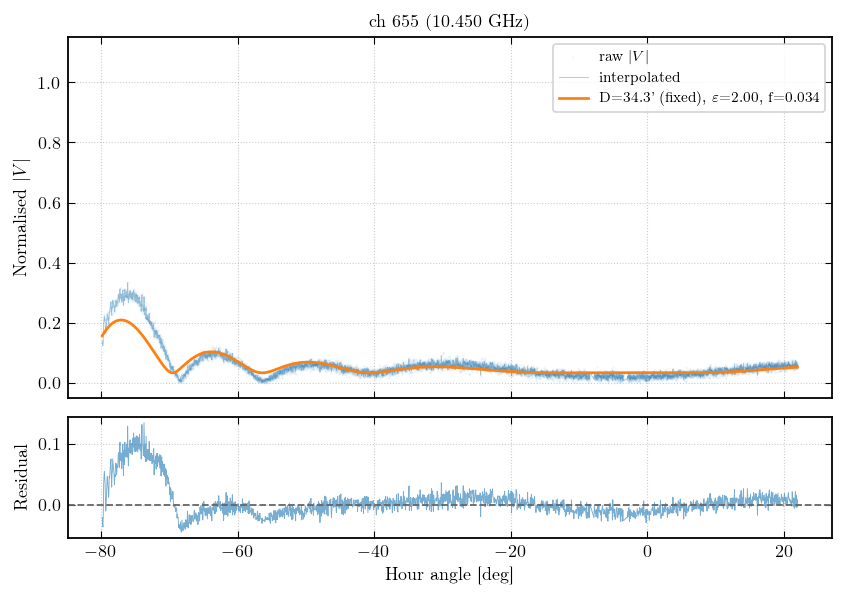

In [6]:
fr = res

freq_hz = float(F_SKY_HZ[k_mid])
env_raw = np.abs(corr_dc[:, k_mid])
finite = np.isfinite(env_raw) & np.isfinite(ha_deg_arr)

v_lb_fit = limb_brightened_visibility(fr["q_uni"], fr["R"], fr["eps"])
fit_curve = fr["A"] * np.sqrt(v_lb_fit**2 + fr["f"]**2)

V0 = fr["A"]
D_show = np.rad2deg(2 * fr["R"]) * 60

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.0),
                                      gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
                                      sharex=True)

ax_top.scatter(ha_deg_arr[finite], env_raw[finite] / V0,
               s=0.3, alpha=0.05, color="C0", rasterized=True, label="raw $|V|$")
ax_top.plot(fr["ha_uni"], fr["env_uni"] / V0, lw=0.5, color="C0", alpha=0.4,
            label="interpolated")

fit_label = (f"D={D_show:.1f}' (fixed), "
             rf"$\varepsilon$={fr['eps']:.2f}, "
             f"f={fr['f']:.3f}")
ax_top.plot(fr["ha_uni"], fit_curve / V0, lw=LW_STANDARD, color="C1", label=fit_label)

ax_top.set_ylabel("Normalised $|V|$")
ax_top.set_title(f"ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz)", fontsize=TICK_SIZE)
ax_top.legend(fontsize=TICK_SIZE - 2, loc="upper right")
ax_top.set_ylim(-0.05, 1.15)
ax_top.tick_params(labelbottom=False)

resid = fr["env_uni"] / V0 - fit_curve / V0
ax_bot.plot(fr["ha_uni"], resid, lw=0.5, color="C0", alpha=0.6)
ax_bot.axhline(0, color="0.4", lw=LW_LIGHT, ls="--")
ax_bot.set_xlabel("Hour angle [deg]")
ax_bot.set_ylabel("Residual")

fig.tight_layout()
plt.show()

## 5. Fit all channels

In [7]:
print(f"Fitting all {len(all_ch)} channels (3-param, R+baseline fixed)...")
fit_results = {}
for i, k in enumerate(all_ch):
    r = fit_channel(k)
    if r is not None:
        fit_results[k] = {key: r[key] for key in ["A", "eps", "f", "R",
                                                    "A_err", "eps_err", "f_err"]}
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(all_ch)} done, {len(fit_results)} converged")

print(f"\nConverged: {len(fit_results)} / {len(all_ch)} channels")

Fitting all 285 channels (3-param, R+baseline fixed)...
  50/285 done, 50 converged
  100/285 done, 100 converged
  150/285 done, 150 converged
  200/285 done, 200 converged
  250/285 done, 250 converged

Converged: 285 / 285 channels


## 6. Results: fitted parameters vs frequency

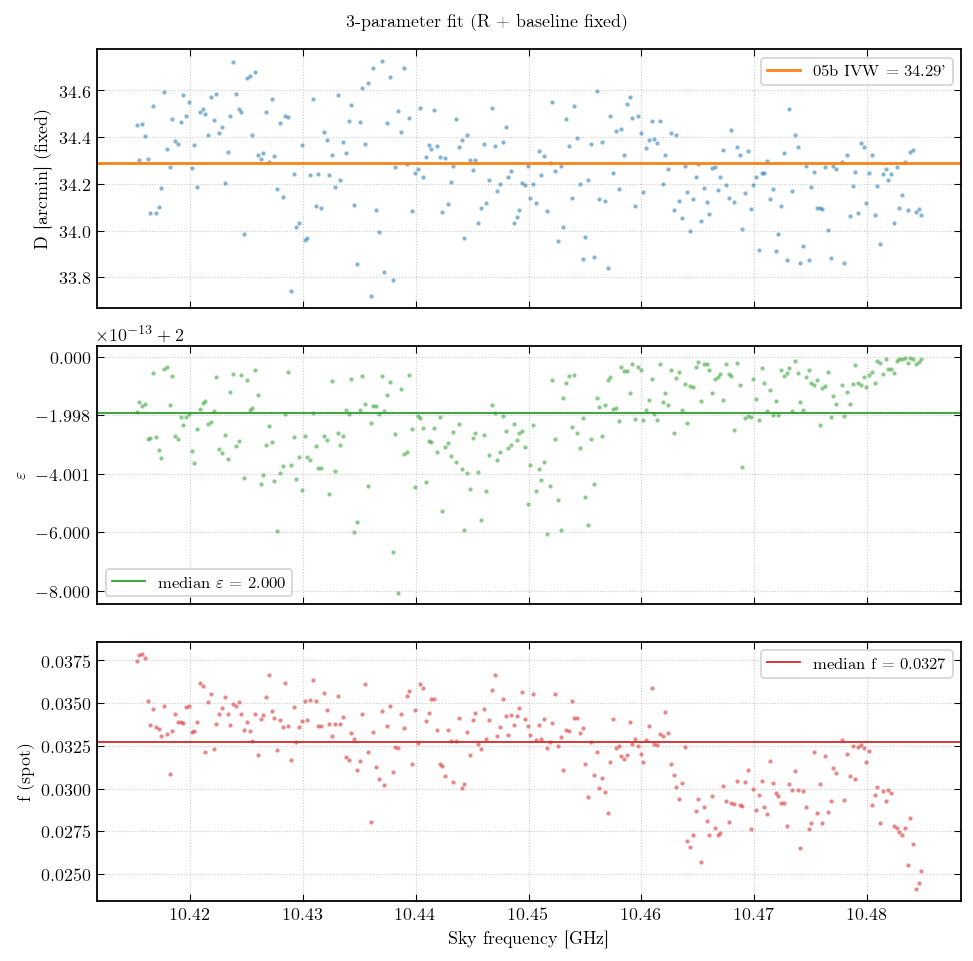

Median eps: 2.0000
Median f: 0.0327


In [8]:
fit_keys = sorted(fit_results.keys())
fit_freqs = np.array([F_SKY_GHZ[k] for k in fit_keys])
fit_D     = np.array([np.rad2deg(2 * fit_results[k]["R"]) * 60 for k in fit_keys])
fit_eps   = np.array([fit_results[k]["eps"] for k in fit_keys])
fit_f     = np.array([fit_results[k]["f"] for k in fit_keys])

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 7.5), sharex=True)

ax = axes[0]
ax.plot(fit_freqs, fit_D, ".", ms=3, color="C0", alpha=0.4)
ax.axhline(D_ivw_05b, color="C1", lw=LW_STANDARD,
           label=f"05b IVW = {D_ivw_05b:.2f}'")
ax.set_ylabel("D [arcmin] (fixed)")
ax.legend(fontsize=TICK_SIZE - 1)

ax = axes[1]
ax.plot(fit_freqs, fit_eps, ".", ms=3, color="C2", alpha=0.4)
ax.axhline(np.median(fit_eps), color="C2", lw=LW_LIGHT,
           label=rf"median $\varepsilon$ = {np.median(fit_eps):.3f}")
ax.set_ylabel(r"$\varepsilon$")
ax.legend(fontsize=TICK_SIZE - 1)

ax = axes[2]
ax.plot(fit_freqs, fit_f, ".", ms=3, color="C3", alpha=0.4)
ax.axhline(np.median(fit_f), color="C3", lw=LW_LIGHT,
           label=f"median f = {np.median(fit_f):.4f}")
ax.set_ylabel("f (spot)")
ax.set_xlabel("Sky frequency [GHz]")
ax.legend(fontsize=TICK_SIZE - 1)

fig.suptitle("3-parameter fit (R + baseline fixed)", fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

print(f"Median eps: {np.median(fit_eps):.4f}")
print(f"Median f: {np.median(fit_f):.4f}")